In [1]:
# Install a pip package in the current Jupyter notebook - if you have not had them installed already
import sys
!{sys.executable} -m pip install numpy
#!pip install numpy #this is not recommended see: https://jakevdp.github.io/blog/2017/12/05/installing-python-packages-from-jupyter/

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!{sys.executable} -m pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [3]:
#import the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import os

In [4]:
#dimensions and parameters
xPixels = 400 #number of voxels in x direction
yPixels = 400 #number of voxels in y direction
zPixels = 220 #number of voxels in z direction
xPixel_size = 0.5 #size of each pixel in x direction and in mm
yPixel_size = 0.5 #mm
zPixel_size = 0.5 #mm
inner_rd    = 69 #mm
outter_rd   = 70 #mm
width       = 28.6 #mm
nSamples    = 10000

In [5]:
#Monte Carlo simulation - the phanum here is an annulus
def MonteCarlo_sim(nSamples, xPixels, yPixels, xPixel_size, yPixel_size):
    xCenter     = xPixels/2
    yCenter     = yPixels/2
    arrImage2D  = np.zeros((xPixels, yPixels), dtype=np.float32) 
    
    xPoints     = np.random.uniform(low=0.0, high=xPixel_size, size=nSamples)
    yPoints     = np.random.uniform(low=0.0, high=yPixel_size, size=nSamples)
    
    for j in range(yPixels):
        for i in range(xPixels):
            
                #xCondition1 = ((i-xCenter)*xPixel_size + xPoints) > inner_rd
                #xCondition2 = ((i-xCenter)*xPixel_size + xPoints) < outter_rd
                #xCondition = xCondition1 & xCondition2
            
                #North
                xCondition1 = ((i-xCenter)*xPixel_size + xPoints) > -width
                xCondition2 = ((i-xCenter)*xPixel_size + xPoints) < width
                xCondition = xCondition1 & xCondition2
            
                yCondition1 = ((j-yCenter)*yPixel_size + yPoints) > inner_rd
                yCondition2 = ((j-yCenter)*yPixel_size + yPoints) < outter_rd
                yCondition = yCondition1 & yCondition2

                condition_north = xCondition & yCondition

                #North East
                xCondition1 = (np.sqrt(2)/2)*(((i-xCenter)*xPixel_size + xPoints) - ((j-yCenter)*yPixel_size + yPoints)) > -width #((np.sqrt(2)/2) * (-1 * (width + inner_rd))) 
                xCondition2 = (np.sqrt(2)/2)*(((i-xCenter)*xPixel_size + xPoints) - ((j-yCenter)*yPixel_size + yPoints)) < width #((np.sqrt(2)/2) * (width - outter_rd))
                xCondition = xCondition1 & xCondition2
            
                yCondition1 = (np.sqrt(2)/2)*(((i-xCenter)*xPixel_size + xPoints) + ((j-yCenter)*yPixel_size + yPoints)) > inner_rd #((np.sqrt(2)/2) * ((-1*width) + inner_rd)) 
                yCondition2 = (np.sqrt(2)/2)*(((i-xCenter)*xPixel_size + xPoints) + ((j-yCenter)*yPixel_size + yPoints)) < outter_rd #((np.sqrt(2)/2) * (width + outter_rd)) 
                yCondition = yCondition1 & yCondition2

                condition_north_east = xCondition & yCondition

                #East
                xCondition1 = ((i-xCenter)*xPixel_size + xPoints) > inner_rd
                xCondition2 = ((i-xCenter)*xPixel_size + xPoints) < outter_rd
                xCondition = xCondition1 & xCondition2
            
                yCondition1 = ((j-yCenter)*yPixel_size + yPoints) > -width
                yCondition2 = ((j-yCenter)*yPixel_size + yPoints) < width
                yCondition = yCondition1 & yCondition2

                condition_east = xCondition & yCondition

                #South East
                xCondition1 = (np.sqrt(2)/2)*(((i-xCenter)*xPixel_size + xPoints) - ((j-yCenter)*yPixel_size + yPoints)) > inner_rd #((np.sqrt(2)/2) * (-1 * (width + inner_rd))) 
                xCondition2 = (np.sqrt(2)/2)*(((i-xCenter)*xPixel_size + xPoints) - ((j-yCenter)*yPixel_size + yPoints)) < outter_rd #((np.sqrt(2)/2) * (width - outter_rd))
                xCondition = xCondition1 & xCondition2
            
                yCondition1 = (np.sqrt(2)/2)*(((i-xCenter)*xPixel_size + xPoints) + ((j-yCenter)*yPixel_size + yPoints)) > -width #((np.sqrt(2)/2) * ((-1*width) + inner_rd)) 
                yCondition2 = (np.sqrt(2)/2)*(((i-xCenter)*xPixel_size + xPoints) + ((j-yCenter)*yPixel_size + yPoints)) < width #((np.sqrt(2)/2) * (width + outter_rd)) 
                yCondition = yCondition1 & yCondition2

                condition_south_east = xCondition & yCondition

                #South
                xCondition1 = ((i-xCenter)*xPixel_size + xPoints) > - width
                xCondition2 = ((i-xCenter)*xPixel_size + xPoints) < width
                xCondition = xCondition1 & xCondition2
            
                yCondition1 = -((j-yCenter)*yPixel_size + yPoints) > inner_rd
                yCondition2 = -((j-yCenter)*yPixel_size + yPoints) < outter_rd
                yCondition = yCondition1 & yCondition2

                condition_south = xCondition & yCondition

                #South West
                xCondition1 = (np.sqrt(2)/2)*(((i-xCenter)*xPixel_size + xPoints) - ((j-yCenter)*yPixel_size + yPoints)) > - width #((np.sqrt(2)/2) * (-1 * (width + inner_rd))) 
                xCondition2 = (np.sqrt(2)/2)*(((i-xCenter)*xPixel_size + xPoints) - ((j-yCenter)*yPixel_size + yPoints)) < width #((np.sqrt(2)/2) * (width - outter_rd))
                xCondition = xCondition1 & xCondition2
            
                yCondition1 = (-np.sqrt(2)/2)*(((i-xCenter)*xPixel_size + xPoints) + ((j-yCenter)*yPixel_size + yPoints)) > inner_rd #((np.sqrt(2)/2) * ((-1*width) + inner_rd)) 
                yCondition2 = (-np.sqrt(2)/2)*(((i-xCenter)*xPixel_size + xPoints) + ((j-yCenter)*yPixel_size + yPoints)) < outter_rd #((np.sqrt(2)/2) * (width + outter_rd)) 
                yCondition = yCondition1 & yCondition2

                condition_south_west = xCondition & yCondition

                #West
                xCondition1 = -((i-xCenter)*xPixel_size + xPoints) > inner_rd
                xCondition2 = -((i-xCenter)*xPixel_size + xPoints) < outter_rd
                xCondition = xCondition1 & xCondition2
            
                yCondition1 = ((j-yCenter)*yPixel_size + yPoints) > -width
                yCondition2 = ((j-yCenter)*yPixel_size + yPoints) < width
                yCondition = yCondition1 & yCondition2

                condition_west = xCondition & yCondition

                #North West
                xCondition1 = (np.sqrt(2)/2)*(((i-xCenter)*xPixel_size + xPoints) + ((j-yCenter)*yPixel_size + yPoints)) > -width #((np.sqrt(2)/2) * (-1 * (width + inner_rd))) 
                xCondition2 = (np.sqrt(2)/2)*(((i-xCenter)*xPixel_size + xPoints) + ((j-yCenter)*yPixel_size + yPoints)) < width #((np.sqrt(2)/2) * (width - outter_rd))
                xCondition = xCondition1 & xCondition2
            
                yCondition1 = (np.sqrt(2)/2)*((-1*((i-xCenter)*xPixel_size + xPoints)) + ((j-yCenter)*yPixel_size + yPoints)) >  inner_rd #((np.sqrt(2)/2) * ((-1*width) + inner_rd)) 
                yCondition2 = (np.sqrt(2)/2)*((-1*((i-xCenter)*xPixel_size + xPoints)) + ((j-yCenter)*yPixel_size + yPoints)) <  outter_rd #((np.sqrt(2)/2) * (width + outter_rd)) 
                yCondition = yCondition1 & yCondition2

                condition_north_west = xCondition & yCondition

                condition = condition_north | condition_north_east | condition_east | condition_south_east | condition_south | condition_south_west | condition_west | condition_north_west
            
                count = np.count_nonzero(condition) 
            
                arrImage2D[i,j] = count / nSamples

    return arrImage2D

In [6]:
##Visualization - making sure that the everything looks good in 2D
def vis2D(a2Dimage, dim_list):
    '''
    a2Dimage -- a 2d image arranged as a 2d arrat
    dim_list -- a list specifying the extend of the image, i.e, [x_min, x_max, y_min, y_max]
    '''
    plt.imshow(a2Dimage.T, origin='lower', extent=dim_list, cmap='hot')
    plt.colorbar(label='Intensity (0-1)')
    plt.title('Image')
    plt.xlabel('mm')
    plt.ylabel('mm')
    plt.gca().set_aspect('equal')
    plt.show()

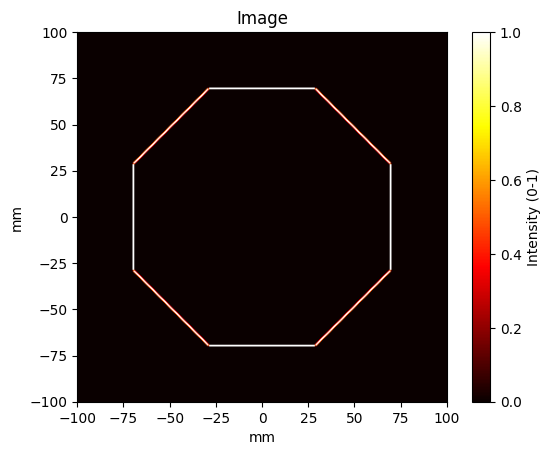

In [7]:
image2d = MonteCarlo_sim(nSamples, xPixels, yPixels, xPixel_size, yPixel_size)
#to test
vis2D(image2d, dim_list = [-(xPixels/2)*xPixel_size, (xPixels/2)*xPixel_size, -(yPixels/2)*yPixel_size, (xPixels/2)*yPixel_size])

In [8]:
#Converting the 2D into the 3D
def twoToThree(image2d, zPixels):
    '''
    image2d -- a 2d image passed as a 2d array
    zPixels -- number of slices/depth/frames
    '''
    arrImage3d = np.zeros(shape=(zPixels, image2d.shape[0], image2d.shape[1]), dtype=np.float32)
    for i in range(zPixels):
        arrImage3d[i,:,:] = image2d
    return arrImage3d

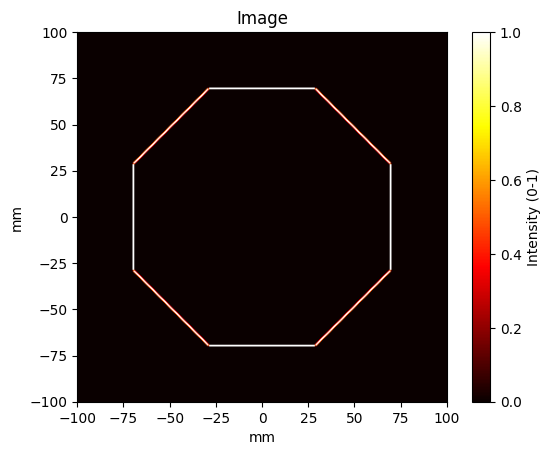

In [9]:
image3d = twoToThree(image2d, zPixels)
#to test
vis2D(image3d[37,:,:], dim_list = [-(xPixels/2)*xPixel_size, (xPixels/2)*xPixel_size, -(yPixels/2)*yPixel_size, (xPixels/2)*yPixel_size])

In [10]:
#https://numpy.org/doc/2.2/reference/generated/numpy.ndarray.tofile.html

#converting 3d array image to a 3d interfile binary image
def interfile_image_generator(arrImage3d):
    '''
    arrImage3d -- a 3d array image (computed above) 
    '''
    #writing the raw binary file
    with open("norm_phantom_image.img", "wb") as f:
        arrImage3d.astype(np.float32).tofile(f)   #astype(np.float32) to get (!number format := short float) and (!number of bytes per pixel := 4)
    
    # Writing interfile header -- you might need to change the following values
    header_content = f"""
    !INTERFILE := 
    !imaging modality := PET
    !version of keys := CASToRv3.2
    CASToR version := 3.2
    
    !GENERAL DATA := 
    !originating system := PET_URNIDDL_PHYTOPET
    !data offset in bytes := 0
    !name of data file := norm_phantom_image.img
    patient name := someone
    
    !GENERAL IMAGE DATA 
    !type of data := Dynamic
    !total number of images := 220
    imagedata byte order := LITTLEENDIAN
    !number of frame groups :=1 
    process status := 
    
    !STATIC STUDY (General) :=
    number of dimensions := 3
    !matrix size [1] := 400
    !matrix size [2] := 400
    !matrix size [3] := 220
    !number format := short float
    !number of bytes per pixel := 4
    scaling factor (mm/pixel) [1] := 0.5
    scaling factor (mm/pixel) [2] := 0.5
    scaling factor (mm/pixel) [3] := 0.5
    first pixel offset (mm) [1] := 0
    first pixel offset (mm) [2] := 0
    first pixel offset (mm) [3] := 0
    data rescale offset := 0
    data rescale slope := 1
    quantification units := 1
    !number of images in this frame group := 220
    !image duration (sec) := 10
    !image start time (sec) := 0
    pause between frame groups (sec) := 0
    !END OF INTERFILE := 
    
    """
    
    with open("norm_phantom_image.hdr", "w") as hdr_file:
        hdr_file.write(header_content)

In [11]:
#a test function for (!number of bytes per pixel := 4) - I was not careful about this at the begining
def num_bytes_per_pixel_test(path_to_img_file): #example in this notebook: path_to_img_file = "norm_phantom_image.img"
    # Read image file size
    bytes_total = os.path.getsize(path_to_img_file)
    voxels = xPixels*yPixels*zPixels
    
    print("Bytes per voxel: ", bytes_total / voxels)  # Should be 4
    print("Bytes in float32: ", np.dtype(np.float32).itemsize) #should be equal to 4 as the above line

In [12]:
interfile_image_generator(image3d)
num_bytes_per_pixel_test(path_to_img_file="norm_phantom_image.img")

Bytes per voxel:  4.0
Bytes in float32:  4
